# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [32]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Jonathan Abraham Bonifacio Moreno"            # Tu nombre completo
MATRICULA = "81832"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutrición"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Jonathan Abraham Bonifacio Moreno
Matrícula: 81832
Dataset asignado: desnutrición


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [33]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\abrah\Desktop\BIG DATA\Examen1\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

DATASET_ASIGNADO = DATASET_ASIGNADO.strip().lower()

# Normaliza la tilde para coincidir con la clave del diccionario
if DATASET_ASIGNADO == "desnutrición":
    DATASET_ASIGNADO = "desnutricion"

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [35]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [36]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [37]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [38]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [39]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [40]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

In [41]:
df["year"].min(), df["year"].max()

(np.int64(2000), np.int64(2024))

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

 El Datset Tiene 3544 registros y 4 columnas que son "entity", "code", "year" y "valor". Solo la columna de "code" tiene 786 valores nulos. Las demás no.
 El rango de años marca del 2000 al 2024
 La variable "year" es numerica y la "valor" es numerica decimal.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [42]:
# Pregunta 1
# Tu codigo aqui
# Pregunta 1

# Pregunta 1


df_paises = df[
    df["code"].str.fullmatch(r"[A-Z]{3}", na=False)
].copy()
cantidad_paises = df_paises["entity"].nunique()
print("Cantidad de países distintos:", cantidad_paises)
cobertura_anual = df_paises.groupby("year")["entity"].nunique()
umbral = cobertura_anual.max() * 0.90
anio_reciente = cobertura_anual[cobertura_anual >= umbral].index.max()
ranking = (
    df_paises[df_paises["year"] == anio_reciente]
    .dropna(subset=["valor"])
    .sort_values("valor", ascending=False)
)
print("Año analizado:", anio_reciente)
print("\n10 países con mayor número de personas subalimentadas:")
display(ranking[["entity", "year", "valor"]].head(10))
print("\n10 países con menor número de personas subalimentadas:")
display(
    ranking[["entity", "year", "valor"]]
    .tail(10)
    .sort_values("valor")
)


Cantidad de países distintos: 139
Año analizado: 2009

10 países con mayor número de personas subalimentadas:


,entity,year,valor
1346,India,2009,184300000.0
640,China,2009,38500000.0
1369,Indonesia,2009,36400000.0
2406,Pakistan,2009,29900000.0
207,Bangladesh,2009,27100000.0
1043,Ethiopia,2009,21000000.0
770,Democratic Republic of Congo,2009,18900000.0
2246,Nigeria,2009,16000000.0
2515,Philippines,2009,15200000.0
3110,Tanzania,2009,10700000.0



10 países con menor número de personas subalimentadas:


,entity,year,valor
2178,New Caledonia,2009,100000.0
1924,Mauritius,2009,100000.0
3018,Suriname,2009,100000.0
2785,Solomon Islands,2009,100000.0
2695,Seychelles,2009,100000.0
2611,Samoa,2009,100000.0
2634,Sao Tome and Principe,2009,100000.0
2588,Saint Vincent and the Grenadines,2009,100000.0
3179,Trinidad and Tobago,2009,100000.0
3342,Vanuatu,2009,100000.0


**Interpretación:**

*(Escribe aquí tu respuesta)*
El Dataset contiene 139 países distintos. En el año 2009, se obtuvo una cobertura máxima de analisis sobre la subalimentación y la desnutrición en ciertos paises. Como lo dice la tabla, el país más subalimentado para esa época fue India, mientras que el país con menor numero de personas subalimentadas es Vanuatu.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [43]:
# Pregunta 2
# Tu codigo aqui
pais1 = "Mexico"
pais2 = "Colombia"
datos_dos_paises = df_paises[
    df_paises["entity"].isin([pais1, pais2])
].copy()
tabla_comun = (
    datos_dos_paises
    .pivot(index="year", columns="entity", values="valor")
    .dropna()
)
resultado_p2 = tabla_comun.reset_index()
print("Rango de años con datos disponibles para ambos países:")
print(resultado_p2["year"].min(), "a", resultado_p2["year"].max())
display(resultado_p2)


Rango de años con datos disponibles para ambos países:
2001 a 2023


entity,year,Colombia,Mexico
0,2001,3400000.0,2800000.0
1,2002,3600000.0,3300000.0
2,2003,3900000.0,3900000.0
3,2004,4300000.0,4300000.0
4,2005,4600000.0,4200000.0
5,2006,4800000.0,4000000.0
6,2007,4700000.0,4000000.0
7,2008,4800000.0,4400000.0
8,2009,4900000.0,4600000.0
9,2010,5000000.0,4600000.0


**Interpretación:**

*(Escribe aquí tu respuesta)*

Se eligieron 2 países "Mexico" y "Colombia" En los cuales se realiza una confirmación de datos disponibles dentro de los años 2001 al 2023, Se puede observar una subalimentación decreciente desde el 2001 que inició con 3.4M, al 2023 que fueron de apenas 2M, mientras que México tuvo resultados mas volatiles dando su punto mas alto de subalimentación en el año 4.6M en varios años, y su punto más bajo fue el año 2001 con apenas 2.8M

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [44]:
# Pregunta 3
# Tu codigo aqui
cinco_paises = ["Mexico", "Brazil", "Ethiopia", "India", "Colombia"]
tabla_p3 = (
    df_paises[df_paises["entity"].isin(cinco_paises)]
    .pivot(index="year", columns="entity", values="valor")
    .dropna()
)
anio_reciente_p3 = tabla_p3.index.max()
comparacion_p3 = (
    tabla_p3.loc[anio_reciente_p3]
    .sort_values(ascending=False)
)
print("Año comparado:", anio_reciente_p3)
print("\nPersonas subalimentadas por país:")
display(comparacion_p3)
pais_mayor = comparacion_p3.index[0]
valor_mayor = comparacion_p3.iloc[0]
pais_menor = comparacion_p3.index[-1]
valor_menor = comparacion_p3.iloc[-1]
diferencia = valor_mayor - valor_menor
print(f"\nValor más alto: {pais_mayor} — {valor_mayor:,.0f}")
print(f"Valor más bajo: {pais_menor} — {valor_menor:,.0f}")
print(f"Diferencia: {diferencia:,.0f} personas")

Año comparado: 2022

Personas subalimentadas por país:


entity
India       192000000.0
Ethiopia     25300000.0
Brazil        6700000.0
Mexico        3600000.0
Colombia      2100000.0
Name: 2022, dtype: float64


Valor más alto: India — 192,000,000
Valor más bajo: Colombia — 2,100,000
Diferencia: 189,900,000 personas


**Interpretación:**

*(Escribe aquí tu respuesta)*

En el año 2022, el país con mayor numero de personas subalimntadas fue India, con 192M. Mientras que el valor más bajo corresponde a Colombia, con 2.1M. La diferencia fue de 189.9M 

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [45]:
# Pregunta 4
# Tu codigo aqui

latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Indonesia", "Vietnam"]
todos_los_paises = latinoamerica + asia
tabla_p4 = (
    df_paises[df_paises["entity"].isin(todos_los_paises)]
    .pivot(index="year", columns="entity", values="valor")
)
tabla_completa_p4 = tabla_p4.dropna()
anio_reciente_p4 = tabla_completa_p4.index.max()
valores_p4 = tabla_completa_p4.loc[anio_reciente_p4]
promedio_latinoamerica = valores_p4[latinoamerica].mean()
promedio_asia = valores_p4[asia].mean()
resultado_p4 = pd.DataFrame({
    "Grupo": ["Latinoamérica", "Asia"],
    "Promedio de personas subalimentadas": [
        promedio_latinoamerica,
        promedio_asia
    ]
})
print("Año comparado:", anio_reciente_p4)
display(resultado_p4)
print("\nValores individuales:")
display(valores_p4)

Año comparado: 2009


,Grupo,Promedio de personas subalimentadas
0,Latinoamérica,3.633333e+06
1,Asia,2.820000e+07



Valores individuales:


entity
Argentina     1400000.0
China        38500000.0
Colombia      4900000.0
Indonesia    36400000.0
Mexico        4600000.0
Vietnam       9700000.0
Name: 2009, dtype: float64

**Interpretación:**

*(Escribe aquí tu respuesta)*

En el año 2009, el promedio de personas subalimentadas en Lationamerica fue de 3.63333, mientras que en Asia fue de 2.82000. El grupo con el promedio más alto fue Latinoamerica.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [46]:
# Pregunta 5
# Tu codigo aqui

pais_tendencia = "Mexico"
serie_p5 = (
    df_paises[df_paises["entity"] == pais_tendencia]
    .dropna(subset=["valor"])
    .sort_values("year")
)
valor_maximo = serie_p5["valor"].max()
anios_maximos = serie_p5.loc[
    serie_p5["valor"] == valor_maximo, "year"
].tolist()
valor_minimo = serie_p5["valor"].min()
anios_minimos = serie_p5.loc[
    serie_p5["valor"] == valor_minimo, "year"
].tolist()
print("País:", pais_tendencia)
print(f"Máximo: {valor_maximo:,.0f} personas; año(s): {anios_maximos}")
print(f"Mínimo: {valor_minimo:,.0f} personas; año(s): {anios_minimos}")
display(serie_p5[["year", "valor"]])

País: Mexico
Máximo: 4,600,000 personas; año(s): [2009, 2010, 2017]
Mínimo: 2,800,000 personas; año(s): [2001]


,year,valor
1964,2001,2800000.0
1965,2002,3300000.0
1966,2003,3900000.0
1967,2004,4300000.0
1968,2005,4200000.0
1969,2006,4000000.0
1970,2007,4000000.0
1971,2008,4400000.0
1972,2009,4600000.0
1973,2010,4600000.0


**Interpretación:**

*(Escribe aquí tu respuesta)*

En México, el numero de personas subalimentadas tuvo un comportamiento fluctuante entre 2001 y 2023. El valor minimo fue apenas 2.8M en 2001, mientras que el máximo fue de 4.6M en 2009,2010 y 2017. Apartir de ese ultimo periodo más alto, el indicador mostró una disminución en el periodo mas reciente.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [47]:
# Pregunta 6
# Tu codigo aqui
mexico_p6 = (
    df_paises[df_paises["entity"] == "Mexico"]
    .dropna(subset=["valor"])
    .sort_values("year")
)
primer_registro = mexico_p6.iloc[0]
ultimo_registro = mexico_p6.iloc[-1]
cambio_porcentual = (
    (ultimo_registro["valor"] - primer_registro["valor"])
    / primer_registro["valor"]
) * 100
print(
    f"Primer año: {int(primer_registro['year'])} "
    f"— {primer_registro['valor']:,.0f} personas"
)
print(
    f"Último año: {int(ultimo_registro['year'])} "
    f"— {ultimo_registro['valor']:,.0f} personas"
)
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")


Primer año: 2001 — 2,800,000 personas
Último año: 2023 — 3,500,000 personas
Cambio porcentual: 25.00%


**Interpretación:**

*(Escribe aquí tu respuesta)*

México presenta un incremento relativo aproximado de 25% entre 2001 y 2023. Aunque en los años mas recientes fue disminuyendo, el valor final sigue siendo mayor al del inicio.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [48]:
# Pregunta 7
# Tu codigo aqui
cobertura_anual = (
    df_paises
    .dropna(subset=["valor"])
    .groupby("year")["entity"]
    .nunique()
)
umbral = cobertura_anual.max() * 0.90
anio_p7 = cobertura_anual[cobertura_anual >= umbral].index.max()
valores_p7 = (
    df_paises[df_paises["year"] == anio_p7]["valor"]
    .dropna()
    .to_numpy()
)
media = np.mean(valores_p7)
mediana = np.median(valores_p7)
desviacion_estandar = np.std(valores_p7)
print("Año analizado:", anio_p7)
print("Cantidad de países:", len(valores_p7))
print(f"Media: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desviación estándar: {desviacion_estandar:,.2f}")

Año analizado: 2009
Cantidad de países: 120
Media: 5,004,166.67
Mediana: 1,150,000.00
Desviación estándar: 17,741,206.25


**Interpretación:**

*(Escribe aquí tu respuesta)*

En el año 2009 se analizaron 120 países. La media fue de 5,004,166.67 personas subalimentadas y la mediana fue de 1,150,000. Esto significa que unos pocos países con piblaciones grandes y valores altos elevan el promedio. Una desviación estandar alta indica que existen diferencias importantes entre los paises.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

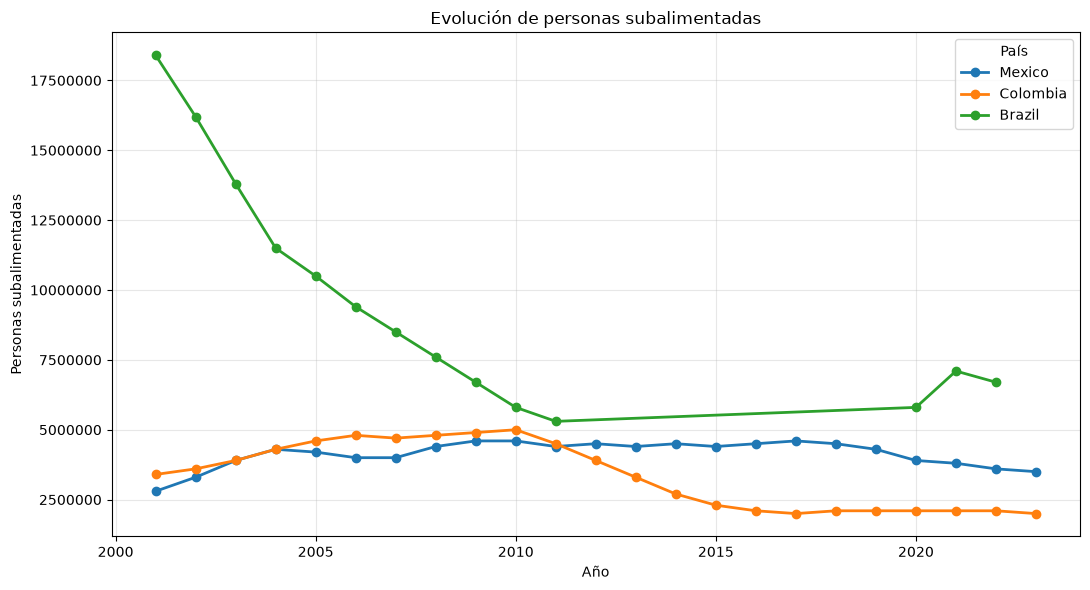

In [49]:
# Pregunta 8
# Tu codigo aqui
paises_grafica = ["Mexico", "Colombia", "Brazil"]
plt.figure(figsize=(11, 6))
for pais in paises_grafica:
    serie = (
        df_paises[df_paises["entity"] == pais]
        .dropna(subset=["valor"])
        .sort_values("year")
    )
    plt.plot(
        serie["year"],
        serie["valor"],
        marker="o",
        linewidth=2,
        label=pais
    )
plt.title("Evolución de personas subalimentadas")
plt.xlabel("Año")
plt.ylabel("Personas subalimentadas")
plt.legend(title="País")
plt.grid(alpha=0.3)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

**Interpretación:**

*(Escribe aquí tu respuesta)*

La gráfica compara la evolución de las personas subalimentadas en México, Colombia y Brasil a lo largo del tiempo. Colombia muestra una disminución importante en el período reciente, mientras que México presenta un comportamiento fluctuante y una disminución después de sus valores máximos. Brasil debe analizarse según la trayectoria observada en la gráfica; las diferencias deben interpretarse considerando que son cifras absolutas y que cada país tiene una población distinta.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

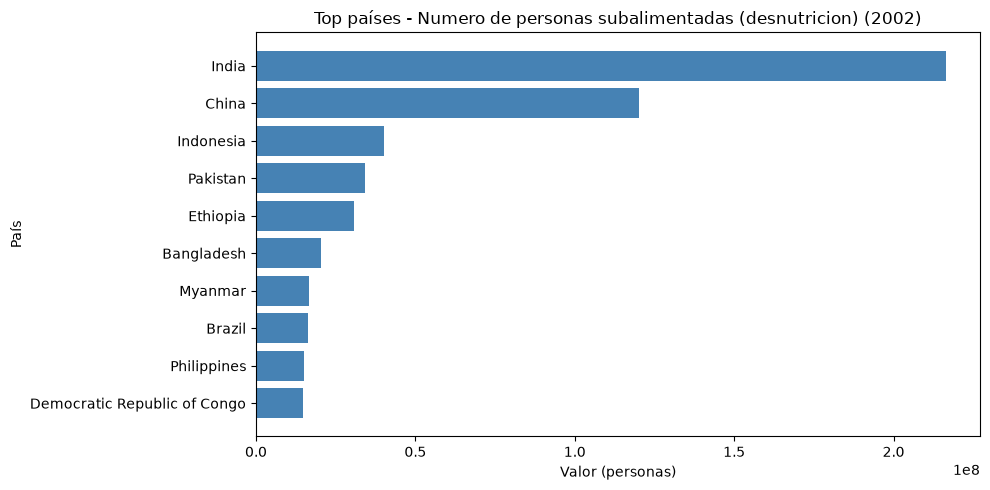

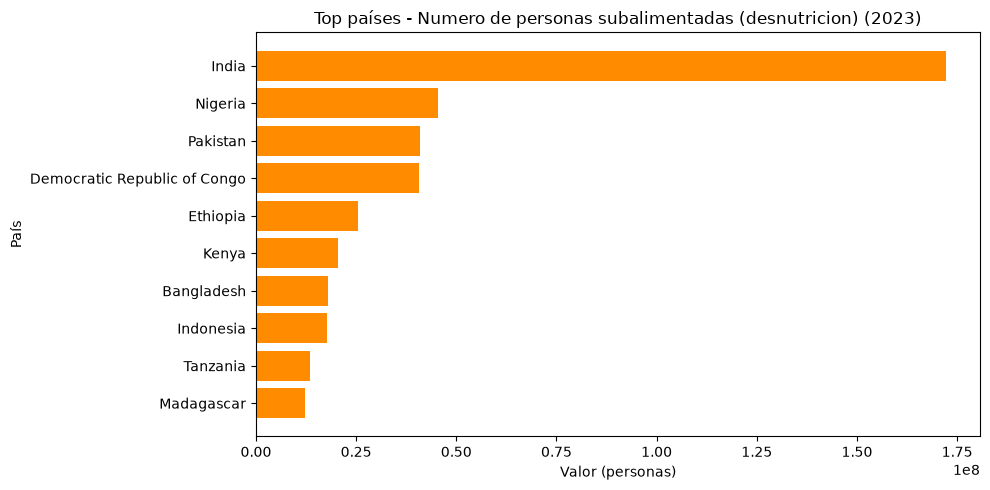

,entity,year,valor
1339,India,2002,216300000.0
633,China,2002,120200000.0
1362,Indonesia,2002,40300000.0
2399,Pakistan,2002,34300000.0
1036,Ethiopia,2002,30900000.0
200,Bangladesh,2002,20300000.0
2102,Myanmar,2002,16600000.0
339,Brazil,2002,16200000.0
2508,Philippines,2002,15200000.0
763,Democratic Republic of Congo,2002,14600000.0


,entity,year,valor
1360,India,2023,172100000.0
2260,Nigeria,2023,45400000.0
2420,Pakistan,2023,40900000.0
784,Democratic Republic of Congo,2023,40700000.0
1057,Ethiopia,2023,25400000.0
1511,Kenya,2023,20400000.0
221,Bangladesh,2023,17900000.0
1383,Indonesia,2023,17700000.0
3124,Tanzania,2023,13400000.0
1826,Madagascar,2023,12300000.0


In [50]:
# Pregunta 9
# Tu codigo aqui
# Pregunta 9
df_paises = df[
    df[config["filtro_paises"]].str.fullmatch(r"[A-Z]{3}", na=False)
].copy()

# ---------- Gráfica 1: año 2002 ----------
anio_consultado = 2002

top_2002 = (
    df_paises[df_paises["year"] == anio_consultado]
    .dropna(subset=["valor"])
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_2002["entity"], top_2002["valor"], color="steelblue")

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ---------- Gráfica 2: año 2023 ----------
anio_consultado = 2023

top_2023 = (
    df_paises[df_paises["year"] == anio_consultado]
    .dropna(subset=["valor"])
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_2023["entity"], top_2023["valor"], color="darkorange")

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_2002[["entity", "year", "valor"]])
display(top_2023[["entity", "year", "valor"]])


**Interpretación:**

*(Escribe aquí tu respuesta)*

Al comparar los rankings de 2002 y 2023, India se mantiene como el país con mayor número de personas subalimentadas, aunque su valor disminuye aproximadamente de 215 a 172 millones. China, que ocupaba el segundo lugar en 2002, ya no aparece en el Top 10 de 2023; también salen Brasil, Myanmar y Filipinas.  
En 2023 ingresan Nigeria, Kenia, Tanzania y Madagascar; además, la República Democrática del Congo sube del décimo al cuarto lugar y Pakistán pasa del cuarto al tercer lugar. Etiopía, Bangladesh e Indonesia permanecen en ambos rankings, aunque Indonesia baja del tercer al octavo puesto. Los resultados son cantidades absolutas, por lo que también reflejan el tamaño de población de cada país y no únicamente la proporción de desnutrición.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*(Escribe aquí tu conclusión)*

El dataset permitió analizar la evolución del número de personas subalimentadas en distintos países entre 2001 y 2023. En México, el indicador aumentó aproximadamente 25% entre 2001 y 2023, aunque presentó una disminución en los años más recientes; Colombia mostró una reducción importante durante el período. Una limitación principal es que los datos son cantidades absolutas y no están normalizados por población, por lo que los países más poblados tienden a presentar cifras mayores. Además, existen códigos faltantes para algunas entidades y no todos los países tienen la misma cobertura temporal. Si tuviera más tiempo, compararía este indicador con el porcentaje de población subalimentada, datos demográficos, pobreza, inflación y acceso a alimentos para realizar un análisis más completo.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
